# Kikilicious Data Analysis


### Overview

Food delivery platforms generate large volumes of transactional data that can be leveraged to understand customer behaviour, restaurant performance, and operational efficiency. The dataset of Kikilicious Foodhub captures orders, customer interactions, delivery times, and ratings within a food delivery ecosystem.

### Objective
To analyse Kikilicious FoodHub’s operational and customer data in order to:
1. Identify patterns in customer ordering behaviour
2. Evaluate restaurant performance and customer satisfaction
3. Assess delivery efficiency and its impact on user ratings
4. Generate data-driven insights that can improve service quality, reduce delays, and enhance customer retention

### Data Description
The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

## Import the Required Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline

## Import Data

In [6]:
df = pd.read_csv("kikilicious_orders.csv")

## Sanity Checks on the Data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [8]:
print(f"Kikilicious dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Kikilicious dataset has 1898 rows and 9 columns.


In [9]:
# First five rows of the dataset
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [10]:
#Last five rows of the dataset
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


* Both the first five and last five rows of the dataset give a general overview or a sneak peek into how what the dataset looks like, the column names and what kind of analysis to expect.

In [11]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


* Kikilicious catered to 1898 orders. The averages of the cost of orders, food preparation time as well the delivery time are summarised here.

In [12]:
df.describe(include = "all")

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898,1898,1898.000000,1898,1898,1898.000000,1898.000000
unique,NaN,NaN,178,14,NaN,2,4,NaN,NaN
top,NaN,NaN,Shake Shack,American,NaN,Weekend,Not given,NaN,NaN
freq,NaN,NaN,219,584,NaN,1351,736,NaN,NaN
mean,1.477496e+06,171168.478398,NaN,NaN,16.498851,NaN,NaN,27.371970,24.161749
std,5.480497e+02,113698.139743,NaN,NaN,7.483812,NaN,NaN,4.632481,4.972637
min,1.476547e+06,1311.000000,NaN,NaN,4.470000,NaN,NaN,20.000000,15.000000
25%,1.477021e+06,77787.750000,NaN,NaN,12.080000,NaN,NaN,23.000000,20.000000
50%,1.477496e+06,128600.000000,NaN,NaN,14.140000,NaN,NaN,27.000000,25.000000
75%,1.477970e+06,270525.000000,NaN,NaN,22.297500,NaN,NaN,31.000000,28.000000


In [13]:
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

* This shows that the dataset has no missing values.

In [14]:
#Checking for datatypes
df.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

The dataset has three different datatypes consisting of categorical and numerical(whole numbers and decimals).

## Orders not Rated

In [15]:
df[["rating"]].value_counts()[["Not given"]]

rating   
Not given    736
Name: count, dtype: int64

736 orders were not rated at all.

## Exploratory Data Analysis (EDA)

### Univariate Analysis

### Variable Distributions

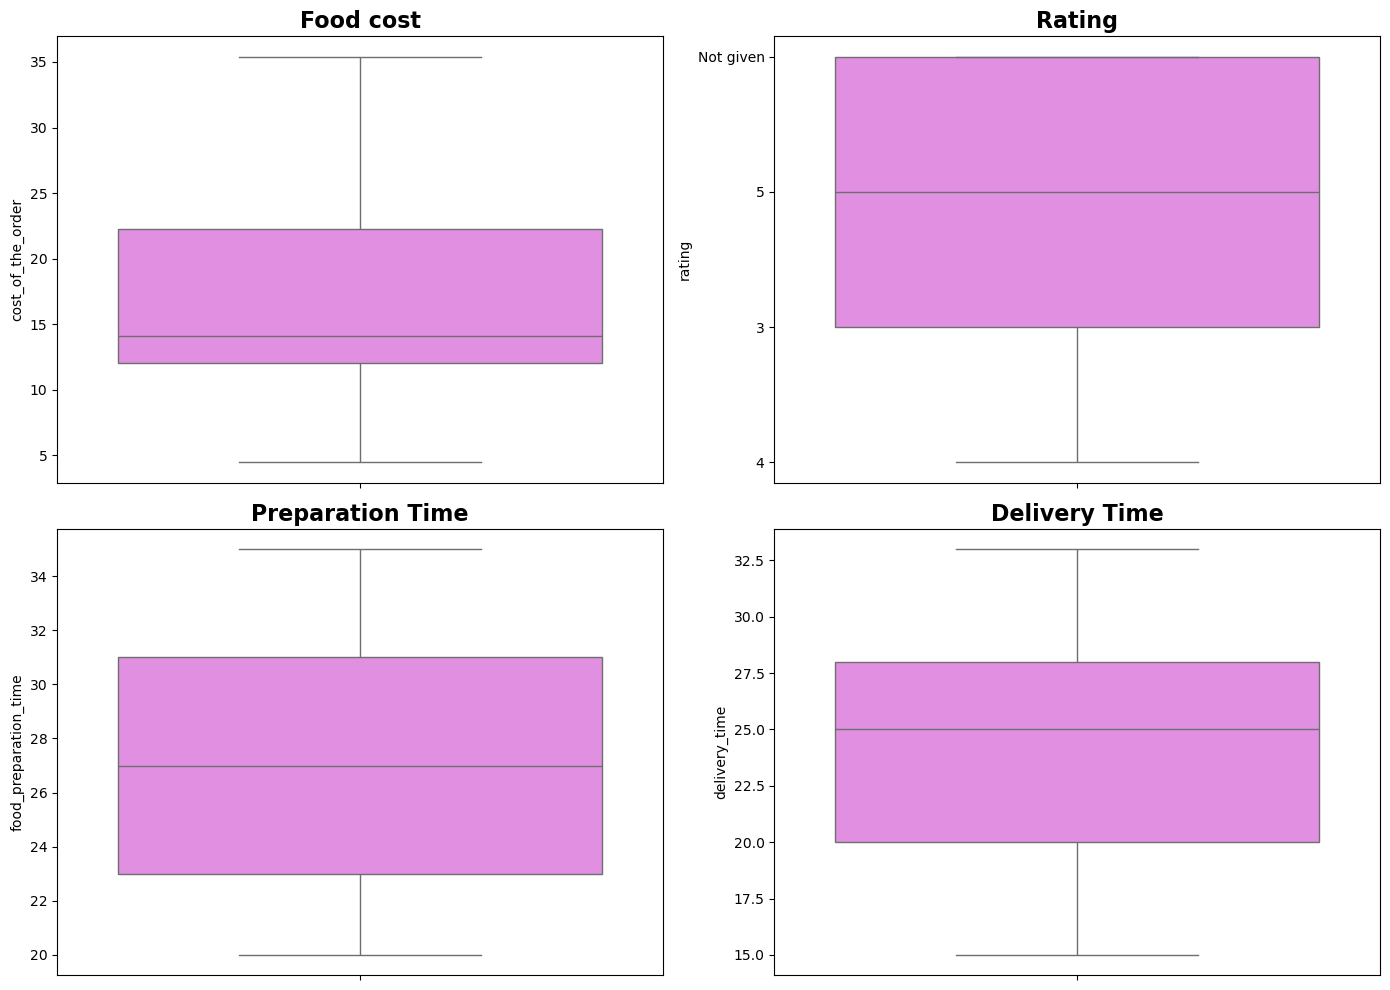

In [16]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.boxplot(df["cost_of_the_order"], color = "violet")
plt.title("Food cost", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,2)
sns.boxplot(df["rating"], color = "violet")
plt.title("Rating", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,3)
sns.boxplot(df["food_preparation_time"], color = "violet")
plt.title("Preparation Time", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,4)
sns.boxplot(df["delivery_time"], color = "violet")
plt.title("Delivery Time", fontweight = "bold", fontsize = 16)
    
plt.tight_layout()
plt.show()

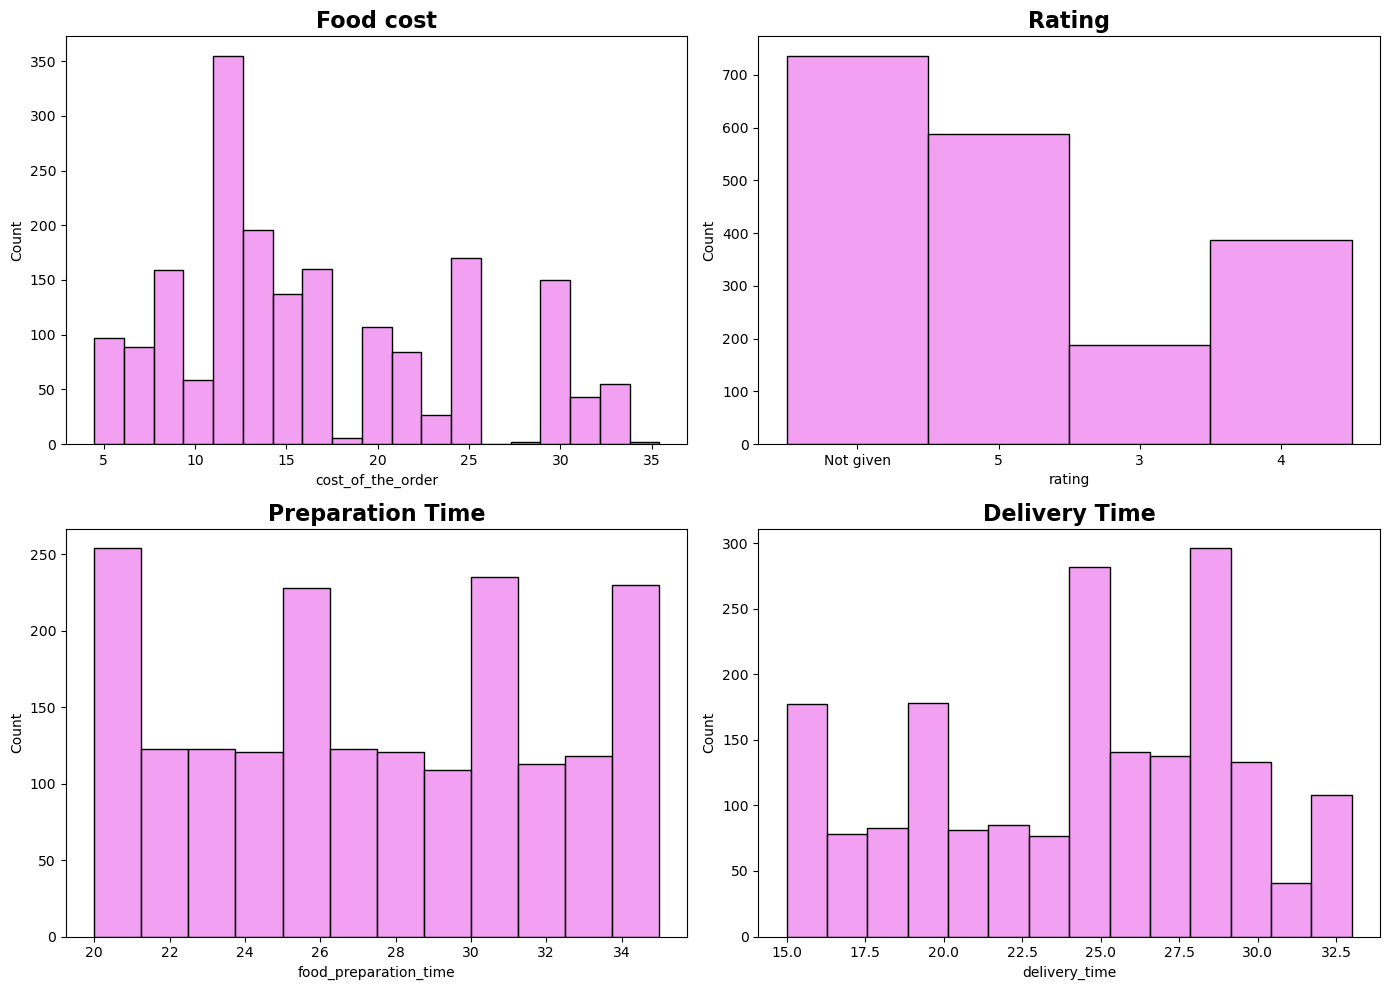

In [17]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.histplot(df["cost_of_the_order"], color = "violet")
plt.title("Food cost", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,2)
sns.histplot(df["rating"], color = "violet")
plt.title("Rating", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,3)
sns.histplot(df["food_preparation_time"], color = "violet")
plt.title("Preparation Time", fontweight = "bold", fontsize = 16)

plt.subplot(2,2,4)
sns.histplot(df["delivery_time"], color = "violet")
plt.title("Delivery Time", fontweight = "bold", fontsize = 16)
    
plt.tight_layout()
plt.show()

In [18]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


* The distributions indicate that the food cost variable is right-skewed, while delivery time is left-skewed. This suggests that only a few orders were relatively expensive, whereas most orders had lower costs. Conversely, only a few deliveries were completed in a short time, with the majority taking longer.

### Visualising cuisine type

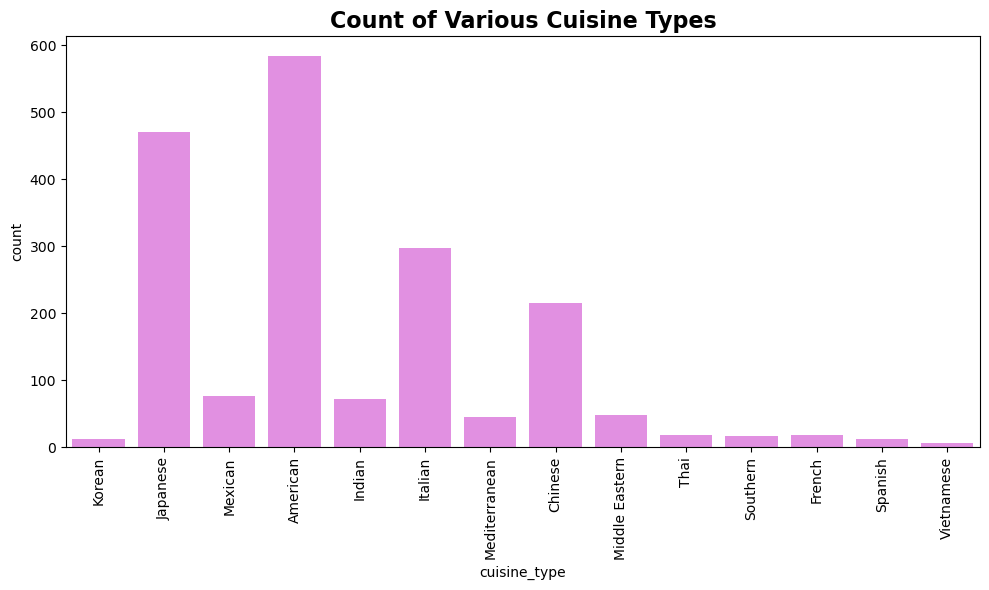

In [19]:
plt.figure(figsize = (10, 6))
sns.countplot(x = df["cuisine_type"], color = "violet")
plt.title("Count of Various Cuisine Types", fontweight = "bold", fontsize = 16)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

* In general, the American cuisine received the most orders. This followed by the Japanese and Italian cuisines respectively.

### Visualising order count by day of the week

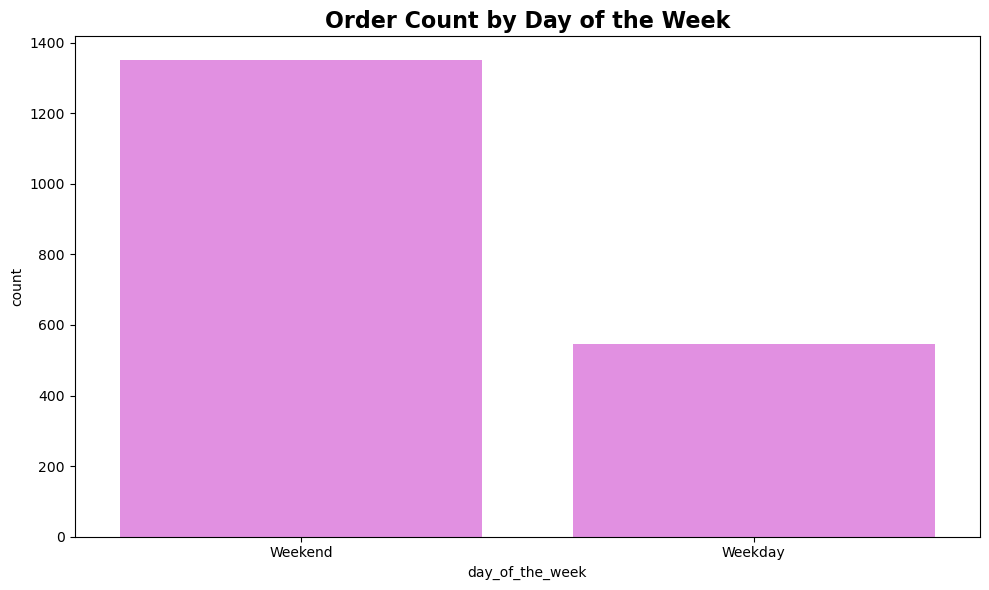

In [20]:
plt.figure(figsize = (10, 6))
sns.countplot(x = df["day_of_the_week"], color = "violet")
plt.title("Order Count by Day of the Week", fontweight = "bold", fontsize = 16)

plt.tight_layout()
plt.show()

* There were more orders on weekends as compared to weekdays.

In [21]:
top_10_r = df["restaurant_name"].value_counts().nlargest(10)
top_10_r= top_10_r.sort_values(ascending=True)
top_10_r

restaurant_name
Blue Ribbon Sushi Bar & Grill     44
Han Dynasty                       46
TAO                               49
RedFarm Hudson                    55
RedFarm Broadway                  59
Parm                              68
Blue Ribbon Fried Chicken         96
Blue Ribbon Sushi                119
The Meatball Shop                132
Shake Shack                      219
Name: count, dtype: int64

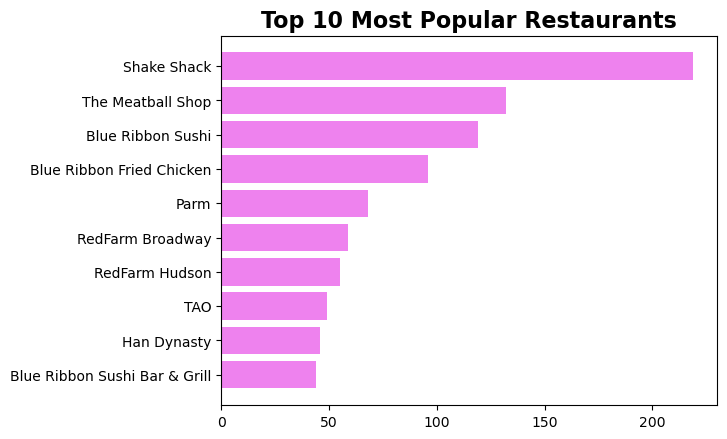

In [22]:
plt.barh(y=top_10_r.index,
           width = top_10_r.values, color = "violet")
plt.title("Top 10 Most Popular Restaurants", fontweight = "bold", fontsize = 16);

### Top 5 restauraurants by orders received

In [23]:
df["restaurant_name"].value_counts().head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

* The top five restaurants to receive the most orders were Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

### Most popular weekend cuisine

In [24]:
count_per_cuisine = df.groupby(["cuisine_type","day_of_the_week"],as_index=False)["order_id"].count()\
        .rename(columns={"order_id":"counts"})\
        .sort_values(by='counts',ascending=False)\
        .reset_index(drop=True)

In [25]:
count_per_cuisine[count_per_cuisine["day_of_the_week"]=="Weekend"].head()

,cuisine_type,day_of_the_week,counts
0,American,Weekend,415
1,Japanese,Weekend,335
2,Italian,Weekend,207
4,Chinese,Weekend,163
7,Mexican,Weekend,53


* American cuisine is the most popular on weekends.

### Percentage of the orders that cost more than 20 dollars

In [26]:
total_order_cost = df["cost_of_the_order"].shape[0]
print(f"Total Order Cost: {df.shape[0]}")

Total Order Cost: 1898


In [27]:
more_than_20 = df[df["cost_of_the_order"]>20].shape[0]
print(f"Orders greater than $20: {more_than_20}")

Orders greater than $20: 555


In [28]:
percentage_above_20 = (more_than_20/total_order_cost)*100
print(f"{percentage_above_20:.2f}% of the orders cost more than $20.")

29.24% of the orders cost more than $20.


### Average delivery time of orders

In [29]:
df["delivery_time"].mean()

np.float64(24.161749209694417)

* It takes about 24 minutes on average for food to be delivered to customers from the pickup to final destinations.

### IDs of the top 3 customers and the number of orders they placed

In [30]:
top_3_customers = df["customer_id"].value_counts().head(3).reset_index()
top_3_customers = top_3_customers.rename(columns = {"count":"order_number"})
top_3_customers

,customer_id,order_number
0,52832,13
1,47440,10
2,83287,9


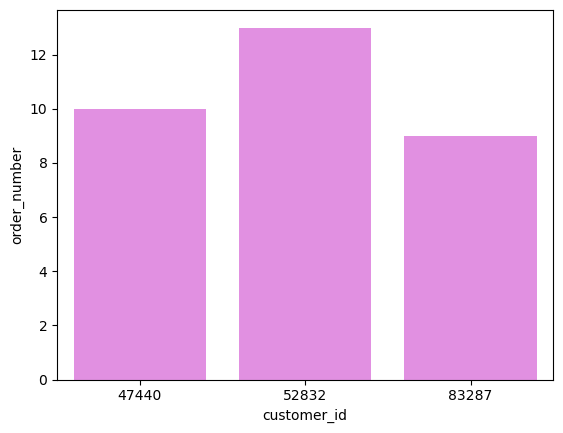

In [31]:
sns.barplot(data = top_3_customers, x = "customer_id", y = "order_number", color = "violet")
plt.show()

* The top three (3) customers had IDs 52832, 47440, and 83287. They placed 13, 10, and 9 orders respectively.

## Bivariate/Multivariate Analysis

### Bivariate/multivariate analysis exploring relationships between the important variables in the dataset


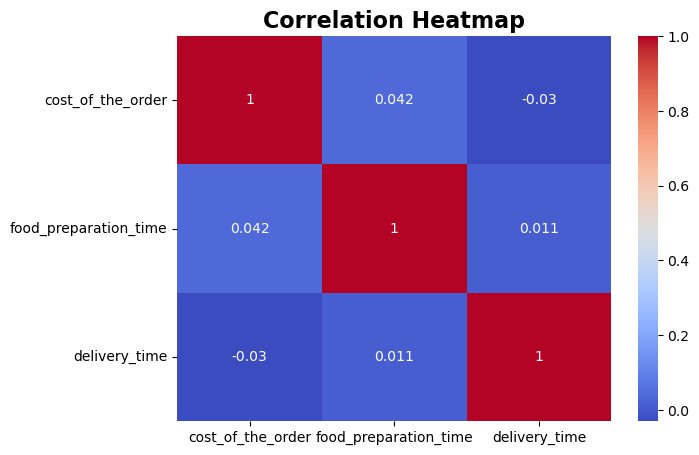

In [32]:
# Correlation between numerical variables
plt.figure(figsize=(7,5))
sns.heatmap(df[["cost_of_the_order", "food_preparation_time", "delivery_time",]].corr(), annot=True, cmap= "coolwarm")
plt.title("Correlation Heatmap", fontweight = "bold", fontsize = 16)
plt.show()

* The correlation matrix indicates that none of the numerical variables exhibit strong correlations with each other. This implies the absence of significant linear relationships, suggesting that variation in one variable does not reliably predict variation in another.

### **Question 9:** Promotional offer based on rating counts of restaurants working with Kikilicious Foodhub

### Conditions for Promotional Offer
Restaurants must have:
* More than 50 ratings
* An average rating greater than 4

In [33]:
df["rating"] = df["rating"].replace("Not given", np.nan)
df["rating"] = pd.to_numeric(df["rating"])

In [34]:
# Group by restaurant
restaurant_stats = df.groupby("restaurant_name")["rating"].agg(["count", "mean"])

# Reset index for readability
restaurant_stats = restaurant_stats.reset_index()

# Filter based on conditions
eligible_restaurants = restaurant_stats[
    (restaurant_stats["count"] > 50) & 
    (restaurant_stats["mean"] > 4)
]

# Display result
eligible_restaurants.sort_values(by = "count", ascending = False)

,restaurant_name,count,mean
136,Shake Shack,133,4.278195
153,The Meatball Shop,84,4.511905
21,Blue Ribbon Sushi,73,4.219178
20,Blue Ribbon Fried Chicken,64,4.328125


* From the analysis, the restaurants eligible for the promotional offer are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken.

### Net revenue based on order cost

### Company Charges on Restuarants:
* 25% on orders greater than $20.00
  
* 15% bon orders greater than $5.00

In [35]:
def compute_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0
        
total_revenue = df['cost_of_the_order'].apply(compute_revenue).sum()
print(f"Net Revenue: ${total_revenue:.2f}")

Net Revenue: $6166.30


### Total time required to deliver the food. Percentage of orders that take more than 60 minutes to get delivered from the time the order is placed

In [36]:
df["total_time"] = df["food_preparation_time"] + df["delivery_time"]
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49


In [37]:
over_60 = df[df["total_time"]>60]
over_60.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,63
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,NaN,34,28,62
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4.0,35,26,61
24,1476714,363783,Cafe Mogador,Middle Eastern,15.86,Weekday,NaN,32,29,61
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3.0,35,29,64


In [38]:
total_orders = df.shape[0]
percentage_over_60 = (over_60.shape[0]/total_orders) * 100
print(f"Percentage of orders over 60 minutes: {percentage_over_60:.2f}%")

Percentage of orders over 60 minutes: 10.54%


### Differences in the delivery time of the orders on weekdays and weekends

In [39]:
avg_delivery_time = df.groupby("day_of_the_week")["delivery_time"].mean()
avg_delivery_time

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

* The results indicate that average delivery times are higher on weekdays than on weekends, suggesting potential differences in demand or operational efficiency across these periods.

## Conclusion and Recommendations

### **Conclusions from the analysis.** 
### Recommendation to help improve the business based on cuisine type and feedback ratings

### Conclusions:
*  Customer Demand Patterns
    * Orders are significantly higher on weekends compared to weekdays, indicating peak demand periods.
    * American cuisine dominates overall orders, followed by Japanese and Italian cuisines, showing clear customer preferences.
* Pricing Insights
    * The cost of orders is right-skewed, meaning most customers place lower-cost orders, with relatively few high-value purchases.
    * Only about 29% of orders exceed $20, suggesting limited penetration of premium pricing.
* Delivery and Operational Efficiency
    * The average delivery time is approximately 24 minutes, which is reasonably efficient.
    * However, about 10.5% of orders take more than 60 minutes, indicating occasional service delays.
    * Delivery times are longer on weekdays than weekends, possibly due to traffic, high demand on weekdays, or operational inefficiencies.
* Customer Engagement and Ratings
    * A large number of orders (736 orders) were not rated, indicating low customer feedback participation.
    * Among rated orders, some restaurants consistently perform well and meet promotional criteria (high ratings and volume).
* Restaurant Performance
    * A few restaurants (e.g., Shake Shack, The Meatball Shop) dominate order volumes, suggesting market concentration.
    * Only a handful of restaurants qualify for promotions based on ratings and review counts.
* Relationships Between Variables
    * There is no strong linear relationship between numerical variables (cost, preparation time, delivery time), meaning performance cannot be predicted using a single factor.

### Recommendations:

*  Improve Customer Feedback Collection
    * Introduce incentives (discounts, loyalty points) to encourage customers to leave ratings.
    * Make rating prompts more visible and easier within the app.
* Reduce Delivery Delays
    * Investigate causes of orders exceeding 60 minutes.
    * Optimise delivery logistics, especially during weekdays (route optimisation, rider allocation).
* Support Underperforming Restaurants
    * Provide insights and training to restaurants with low ratings.
    * Help them improve food quality, preparation time, and packaging.
* Cuisine-Based Marketing
    * Focus marketing efforts on popular cuisines (American, Japanese, Italian).
    * Promote less popular cuisines through discounts or featured listings to diversify demand.